# 3 PCA Analysis

Extract latent attention factors from Google Trends keyword data using Principal Component Analysis. This notebook follows the original project setup: dates are observations, keywords are variables, and each keyword series is standardized before PCA.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    print("Using scikit-learn PCA and StandardScaler")
except ModuleNotFoundError:
    print("scikit-learn not found; using NumPy PCA fallback")

    class StandardScaler:
        def fit(self, X):
            X = np.asarray(X, dtype=float)
            self.mean_ = X.mean(axis=0)
            self.scale_ = X.std(axis=0, ddof=0)
            self.scale_[self.scale_ == 0] = 1.0
            return self

        def transform(self, X):
            return (np.asarray(X, dtype=float) - self.mean_) / self.scale_

        def fit_transform(self, X):
            return self.fit(X).transform(X)

    class PCA:
        def __init__(self, n_components=None):
            self.n_components = n_components

        def fit(self, X):
            X = np.asarray(X, dtype=float)
            self.mean_ = X.mean(axis=0)
            X_centered = X - self.mean_
            _, s, vt = np.linalg.svd(X_centered, full_matrices=False)
            n_keep = self.n_components or vt.shape[0]
            self.components_ = vt[:n_keep]
            explained_variance = (s ** 2) / (X.shape[0] - 1)
            self.explained_variance_ = explained_variance[:n_keep]
            self.explained_variance_ratio_ = explained_variance[:n_keep] / explained_variance.sum()
            self.n_components_ = n_keep
            return self

        def transform(self, X):
            X_centered = np.asarray(X, dtype=float) - self.mean_
            return X_centered @ self.components_.T

        def fit_transform(self, X):
            return self.fit(X).transform(X)


scikit-learn not found; using NumPy PCA fallback


In [2]:
# Load the filtered keyword dataset
DATA_DIR = Path.cwd()
trends_path = DATA_DIR / "trends_final_filtered.csv"

# Preprocessing saves keywords as rows and dates as columns.
trends_keywords = pd.read_csv(trends_path, index_col=0)
trends_keywords.columns = pd.to_datetime(trends_keywords.columns)
trends_keywords = trends_keywords.apply(pd.to_numeric, errors="coerce").fillna(0)

print(f"Raw filtered dataset: {trends_keywords.shape}")
print(f"Keywords (rows): {trends_keywords.shape[0]:,}")
print(f"Time periods (columns): {trends_keywords.shape[1]:,}")
print(f"Date range: {trends_keywords.columns.min().date()} to {trends_keywords.columns.max().date()}")
print(f"Stock market anchor present: {'stock market' in trends_keywords.index}")
print("\nFirst few keywords:")
print(trends_keywords.index[:10].tolist())

trends_keywords.iloc[:5, :5]


Raw filtered dataset: (163, 121)
Keywords (rows): 163
Time periods (columns): 121
Date range: 2016-05-01 to 2026-05-01
Stock market anchor present: False

First few keywords:
['5g', 'advertising', 'aerospace', 'airlines', 'aluminum', 'amazon stock', 'amd stock', 'api', 'apple stock', 'auto parts']


,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01
keyword,,,,,
5g,9.090909,6.666667,10.0,11.111111,10.0
advertising,81.818182,53.333333,80.0,88.888889,90.0
aerospace,27.272727,20.000000,30.0,33.333333,30.0
airlines,1540.000000,1071.428571,1500.0,1825.000000,1575.0
aluminum,172.727273,126.666667,180.0,200.000000,190.0


In [3]:
# Match the original PCA orientation: observations = dates, variables = keywords
trends_data = trends_keywords.T.sort_index()
trends_data.index.name = "date"

# Drop any constant keyword columns before scaling/PCA.
constant_cols = trends_data.columns[trends_data.nunique(dropna=False) <= 1].tolist()
if constant_cols:
    print(f"Dropping {len(constant_cols)} constant columns: {constant_cols}")
    trends_data = trends_data.drop(columns=constant_cols)

print(f"PCA input shape: {trends_data.shape}")
print(f"Observations (dates): {trends_data.shape[0]:,}")
print(f"Variables (keywords): {trends_data.shape[1]:,}")
print("\nKeyword-level summary before standardization:")
print(trends_data.describe().T[["mean", "std", "min", "max"]].head(10))


PCA input shape: (121, 163)
Observations (dates): 121
Variables (keywords): 163

Keyword-level summary before standardization:
                    mean         std         min          max
keyword                                                      
5g             43.407623   25.603173    4.000000   100.000000
advertising    42.110629   18.057236    7.000000    90.000000
aerospace      18.710454    6.626277    3.000000    33.333333
airlines      802.393502  377.310828  121.739130  1825.000000
aluminum      112.779797   37.791868   17.000000   200.000000
amazon stock   35.156272   11.731941   11.111111    62.962963
amd stock      18.960312    9.639510    4.000000    63.157895
api            92.154099   38.642694   13.000000   246.666667
apple stock    33.022056   12.733476   12.000000   100.000000
auto parts    173.257692   85.256079   27.777778   440.000000


In [4]:
# Run PCA on standardized keyword series, as in the original notebook
scaler = StandardScaler()
X_scaled = scaler.fit_transform(trends_data)

pca = PCA()
pc_values = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

print(f"PCA completed with {pca.n_components_} components")
print("\nPC   Variance(%)   Cumulative(%)")
for i in range(min(20, len(explained))):
    print(f"PC{i+1:>2}   {explained[i]:>8.2f}      {cumulative[i]:>8.2f}")

print("\nVariance explained summary:")
print(f"  First 1 PC:  {cumulative[0]:.2f}%")
print(f"  First 5 PCs: {cumulative[4]:.2f}%")
print(f"  First 10 PCs: {cumulative[9]:.2f}%")


PCA completed with 121 components

PC   Variance(%)   Cumulative(%)
PC 1      56.10         56.10
PC 2      13.65         69.75
PC 3       5.78         75.52
PC 4       3.44         78.96
PC 5       2.17         81.13
PC 6       1.84         82.97
PC 7       1.73         84.71
PC 8       1.39         86.09
PC 9       1.17         87.26
PC10       1.00         88.26
PC11       0.87         89.13
PC12       0.76         89.89
PC13       0.71         90.60
PC14       0.62         91.22
PC15       0.53         91.75
PC16       0.50         92.25
PC17       0.48         92.73
PC18       0.39         93.12
PC19       0.38         93.51
PC20       0.37         93.87

Variance explained summary:
  First 1 PC:  56.10%
  First 5 PCs: 81.13%
  First 10 PCs: 88.26%


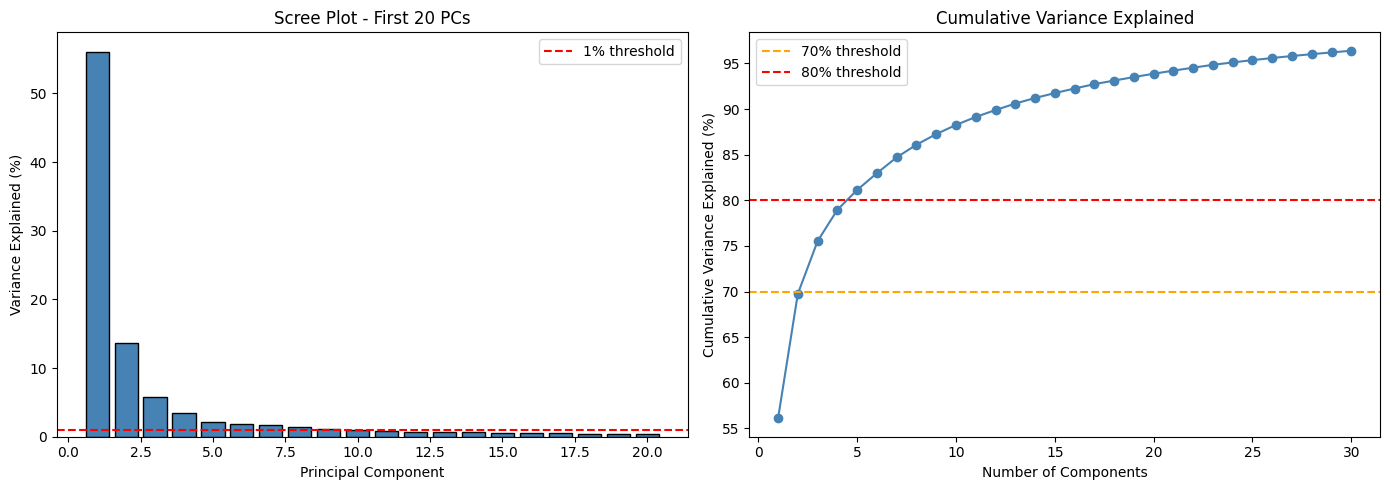

70% variance explained by 3 components
80% variance explained by 5 components
90% variance explained by 13 components


In [5]:
# Scree and cumulative variance plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_bar = min(20, len(explained))
ax1.bar(range(1, n_bar + 1), explained[:n_bar], color="steelblue", edgecolor="black")
ax1.axhline(y=1, color="red", linestyle="--", label="1% threshold")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained (%)")
ax1.set_title("Scree Plot - First 20 PCs")
ax1.legend()

n_line = min(30, len(cumulative))
ax2.plot(range(1, n_line + 1), cumulative[:n_line], marker="o", color="steelblue")
ax2.axhline(y=70, color="orange", linestyle="--", label="70% threshold")
ax2.axhline(y=80, color="red", linestyle="--", label="80% threshold")
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Variance Explained (%)")
ax2.set_title("Cumulative Variance Explained")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"70% variance explained by {np.argmax(cumulative >= 70) + 1} components")
print(f"80% variance explained by {np.argmax(cumulative >= 80) + 1} components")
print(f"90% variance explained by {np.argmax(cumulative >= 90) + 1} components")


In [6]:
# Save PC scores and keyword loadings
pca_scores = pd.DataFrame(
    pc_values,
    index=trends_data.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)

loadings = pd.DataFrame(
    pca.components_.T,
    index=trends_data.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
)

pca_scores_path = DATA_DIR / "pca_scores.csv"
pca_loadings_path = DATA_DIR / "pca_loadings.csv"
pca_scores.to_csv(pca_scores_path)
loadings.to_csv(pca_loadings_path)

print(f"PCA scores saved to: {pca_scores_path.name}")
print(f"PCA scores shape: {pca_scores.shape}  (dates x PCs)")
print(f"PCA loadings saved to: {pca_loadings_path.name}")
print(f"Loadings shape: {loadings.shape}  (keywords x PCs)")
print("\nFirst few PC scores:")
print(pca_scores.iloc[:5, :5])
print("\nFirst few loadings:")
print(loadings.iloc[:5, :5])


PCA scores saved to: pca_scores.csv
PCA scores shape: (121, 121)  (dates x PCs)
PCA loadings saved to: pca_loadings.csv
Loadings shape: (163, 121)  (keywords x PCs)

First few PC scores:
                  PC1       PC2       PC3       PC4       PC5
date                                                         
2016-05-01  15.270874  7.058147  3.219538 -0.661107  2.313337
2016-06-01   1.711560  6.787314  1.805027 -2.083383  3.336154
2016-07-01  17.449749  7.474903 -0.190481 -4.443894  2.812046
2016-08-01  22.880848  7.531968  1.081817 -3.988857  2.021328
2016-09-01  18.340890  6.591766  4.402958  0.554895 -0.400135

First few loadings:
                  PC1       PC2       PC3       PC4       PC5
keyword                                                      
5g          -0.008719 -0.155839 -0.143501 -0.056613 -0.086738
advertising  0.094906  0.050719  0.092971  0.021465 -0.005837
aerospace    0.096033 -0.040929  0.043201 -0.008448  0.021535
airlines     0.092916  0.063718 -0.031551  0.027

In [7]:
# Inspect top keyword loadings for the first few PCs
for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    print("\n" + "=" * 60)
    print(f"Top absolute loadings for {pc}")
    print("=" * 60)
    top = loadings[pc].abs().sort_values(ascending=False).head(15)
    for keyword, abs_loading in top.items():
        sign = "+" if loadings.loc[keyword, pc] > 0 else "-"
        print(f"{sign}{abs_loading:.4f}  {keyword}")



Top absolute loadings for PC1
+0.1025  copper
+0.1024  construction
+0.1008  logistics
+0.1007  manufacturing
+0.1007  oncology
+0.1007  home care
+0.1000  health services
+0.0998  nickel
+0.0994  insurance
+0.0994  clay
+0.0993  cost of living
+0.0993  donation
+0.0992  transportation
+0.0990  aluminum
+0.0989  life insurance

Top absolute loadings for PC2
-0.1976  s&p 500
-0.1805  health it
-0.1775  gpu
-0.1718  etf
-0.1702  ozempic
-0.1563  streaming
-0.1558  5g
+0.1535  online banking
-0.1534  nasdaq
-0.1519  nvidia stock
-0.1505  gold price
-0.1443  inflation
-0.1372  cyber security
-0.1353  interest rates
-0.1351  heat pump

Top absolute loadings for PC3
-0.2404  dow jones
-0.1830  tesla stock
+0.1763  computing
-0.1754  amazon stock
-0.1639  apple stock
+0.1636  robotics
+0.1619  price of gold
-0.1573  fast food
-0.1541  gas station
-0.1506  plant based
-0.1435  5g
+0.1385  oil price
+0.1382  gold price
-0.1334  nasdaq
-0.1333  diagnostics

Top absolute loadings for PC4
+0.2321

## PCA Stability Over Time

Visual checks for the first 13 principal components. The first plots show PC score behavior over time. The rolling-window check refits PCA over 36-month windows and compares each rolling PC loading vector to the full-sample loading vector using absolute cosine similarity, so sign flips do not count as instability.


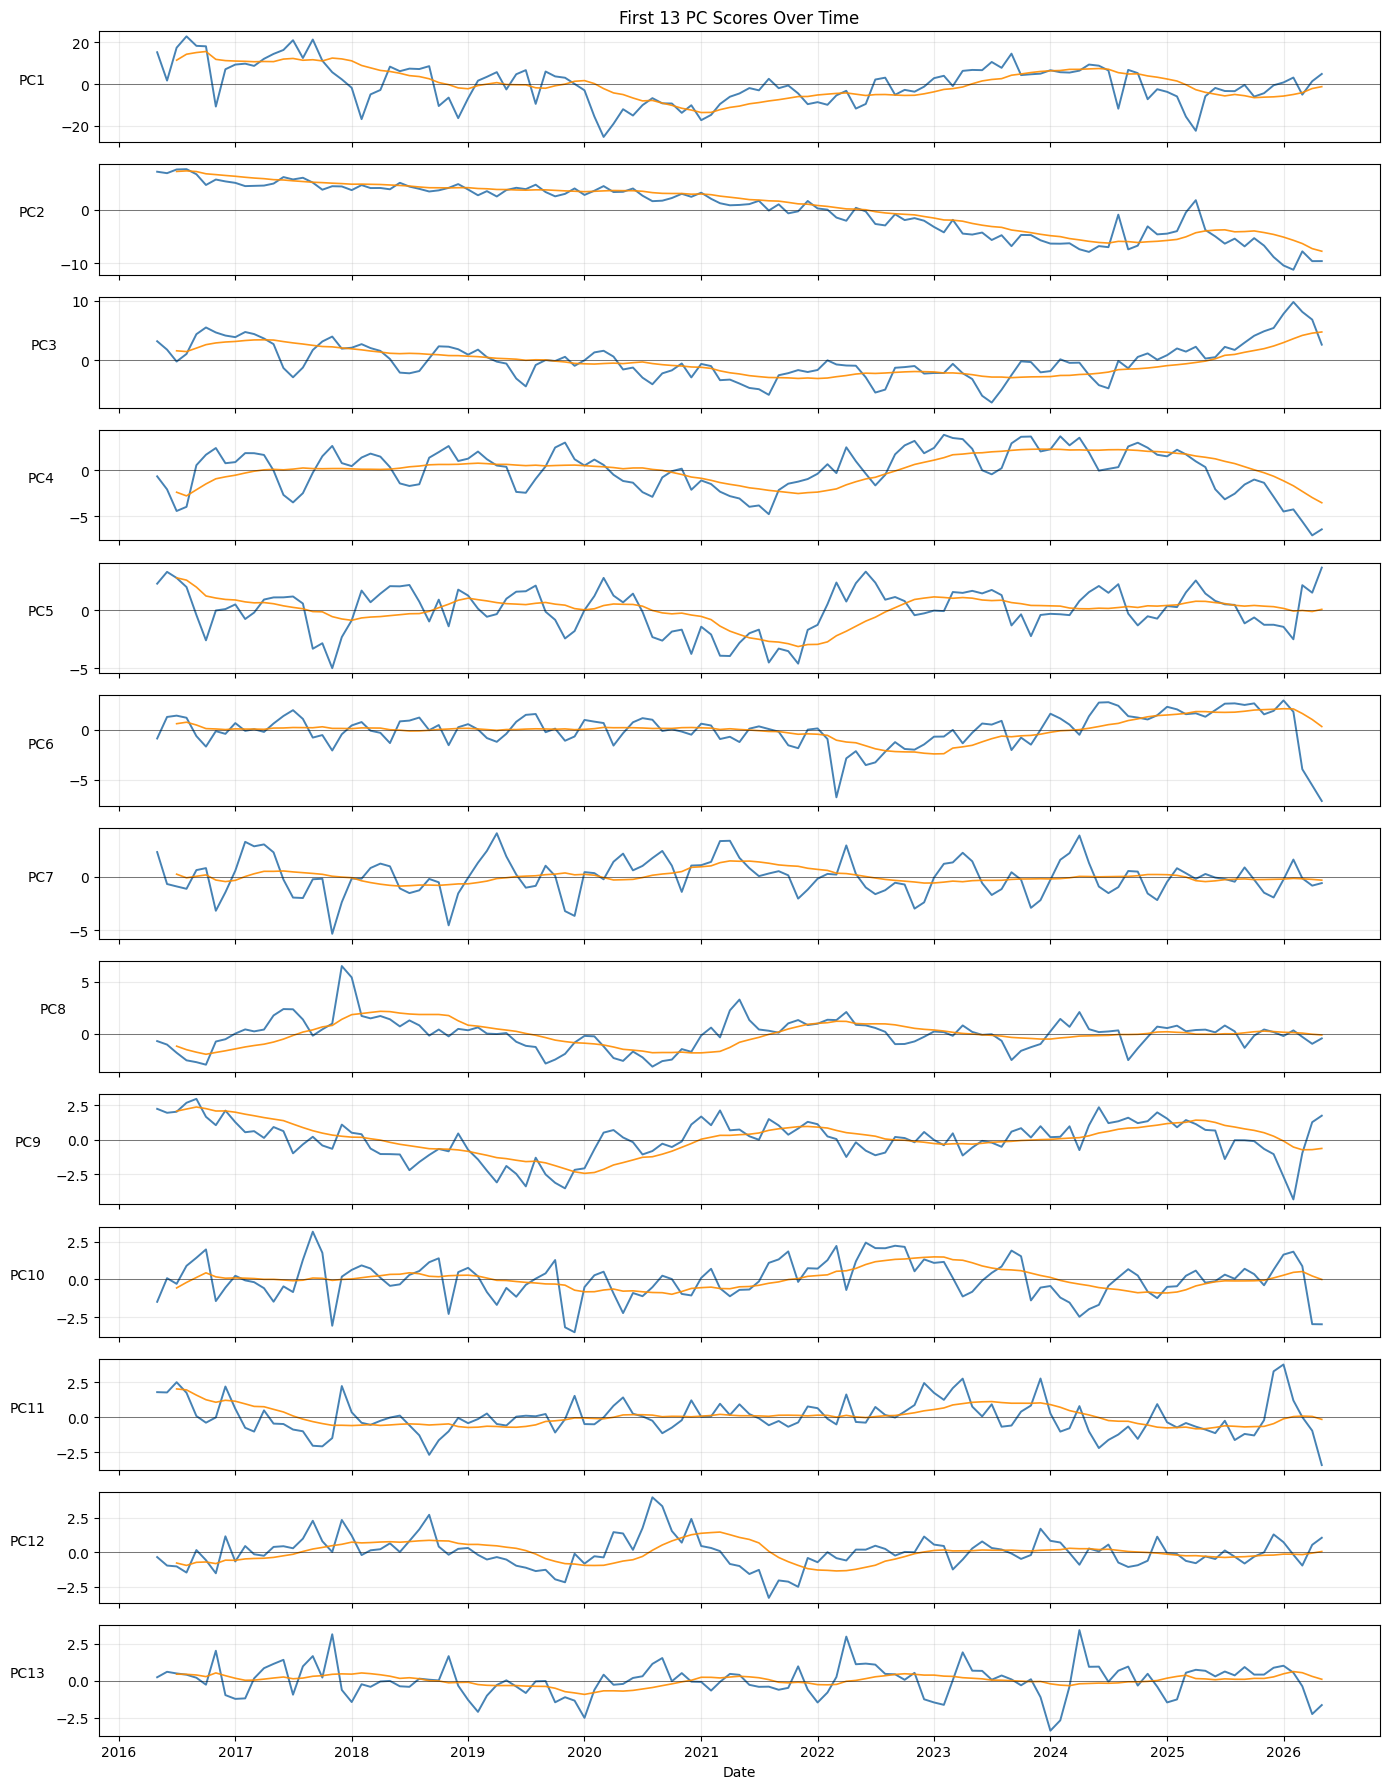

In [8]:
# Plot first 13 PC score time series
N_STABILITY_PCS = 13
score_cols = [f"PC{i}" for i in range(1, N_STABILITY_PCS + 1)]

scores_13 = pca_scores[score_cols]

fig, axes = plt.subplots(N_STABILITY_PCS, 1, figsize=(14, 18), sharex=True)
for ax, pc in zip(axes, score_cols):
    ax.plot(scores_13.index, scores_13[pc], color="steelblue", linewidth=1.4)
    ax.plot(scores_13.index, scores_13[pc].rolling(12, min_periods=3).mean(),
            color="darkorange", linewidth=1.2, alpha=0.9)
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_ylabel(pc, rotation=0, labelpad=20)
    ax.grid(True, alpha=0.25)

axes[0].set_title("First 13 PC Scores Over Time")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


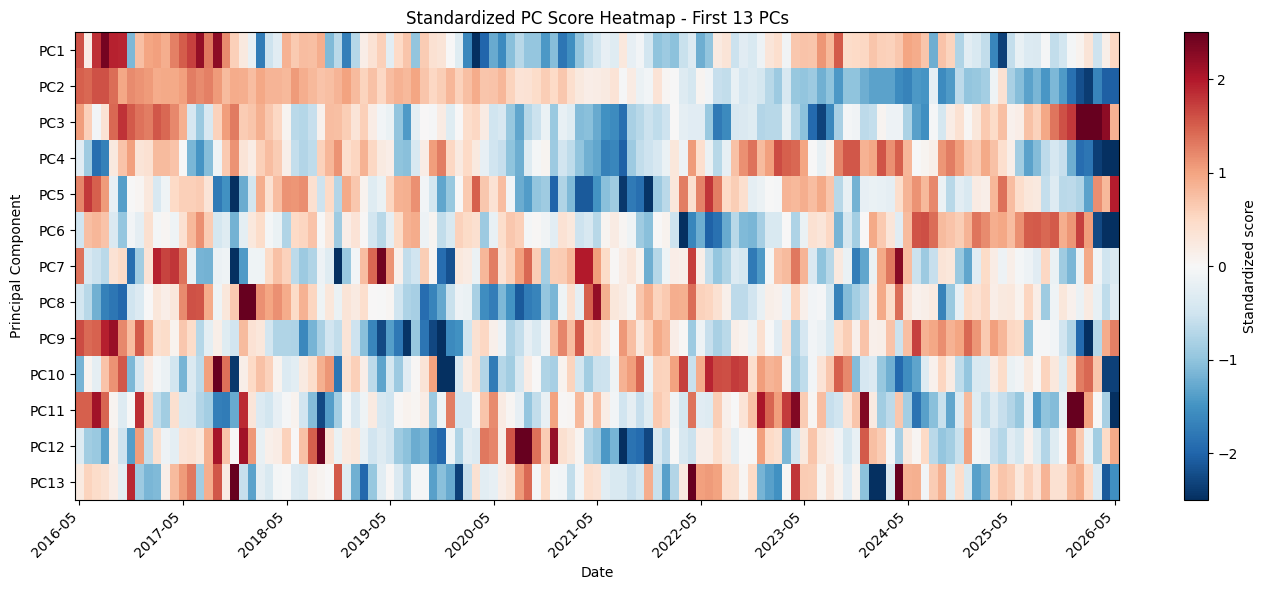

In [9]:
# Heatmap of standardized first 13 PC scores
scores_13_z = (scores_13 - scores_13.mean()) / scores_13.std(ddof=0)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(
    scores_13_z.T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2.5,
    vmax=2.5,
)

ax.set_yticks(range(N_STABILITY_PCS))
ax.set_yticklabels(score_cols)

xticks = np.arange(0, len(scores_13_z.index), 12)
ax.set_xticks(xticks)
ax.set_xticklabels([scores_13_z.index[i].strftime("%Y-%m") for i in xticks], rotation=45, ha="right")
ax.set_title("Standardized PC Score Heatmap - First 13 PCs")
ax.set_xlabel("Date")
ax.set_ylabel("Principal Component")
plt.colorbar(im, ax=ax, label="Standardized score")
plt.tight_layout()
plt.show()


In [10]:
# Rolling-window loading stability against full-sample PCA loadings
ROLLING_WINDOW = 36
N_ROLLING_PCS = 13

full_components = pca.components_[:N_ROLLING_PCS]
rolling_same_rank = []
rolling_best_match = []
rolling_dates = []

for end_pos in range(ROLLING_WINDOW, len(trends_data) + 1):
    window_data = trends_data.iloc[end_pos - ROLLING_WINDOW:end_pos]
    X_window = StandardScaler().fit_transform(window_data)

    pca_window = PCA(n_components=N_ROLLING_PCS)
    pca_window.fit(X_window)
    window_components = pca_window.components_[:N_ROLLING_PCS]

    same_rank_row = []
    best_match_row = []
    for i in range(N_ROLLING_PCS):
        similarities = np.abs(window_components @ full_components[i])
        same_rank_row.append(similarities[i])
        best_match_row.append(similarities.max())

    rolling_same_rank.append(same_rank_row)
    rolling_best_match.append(best_match_row)
    rolling_dates.append(trends_data.index[end_pos - 1])

same_rank_stability = pd.DataFrame(rolling_same_rank, index=rolling_dates, columns=score_cols)
best_match_stability = pd.DataFrame(rolling_best_match, index=rolling_dates, columns=score_cols)

print(f"Rolling window: {ROLLING_WINDOW} months")
print(f"Rolling windows evaluated: {len(same_rank_stability)}")
print("\nAverage same-rank loading similarity:")
print(same_rank_stability.mean().round(3))
print("\nAverage best-match loading similarity:")
print(best_match_stability.mean().round(3))


Rolling window: 36 months
Rolling windows evaluated: 86

Average same-rank loading similarity:
PC1     0.970
PC2     0.363
PC3     0.270
PC4     0.147
PC5     0.195
PC6     0.235
PC7     0.168
PC8     0.161
PC9     0.088
PC10    0.100
PC11    0.159
PC12    0.099
PC13    0.122
dtype: float64

Average best-match loading similarity:
PC1     0.970
PC2     0.427
PC3     0.543
PC4     0.502
PC5     0.525
PC6     0.478
PC7     0.643
PC8     0.449
PC9     0.278
PC10    0.464
PC11    0.401
PC12    0.372
PC13    0.468
dtype: float64


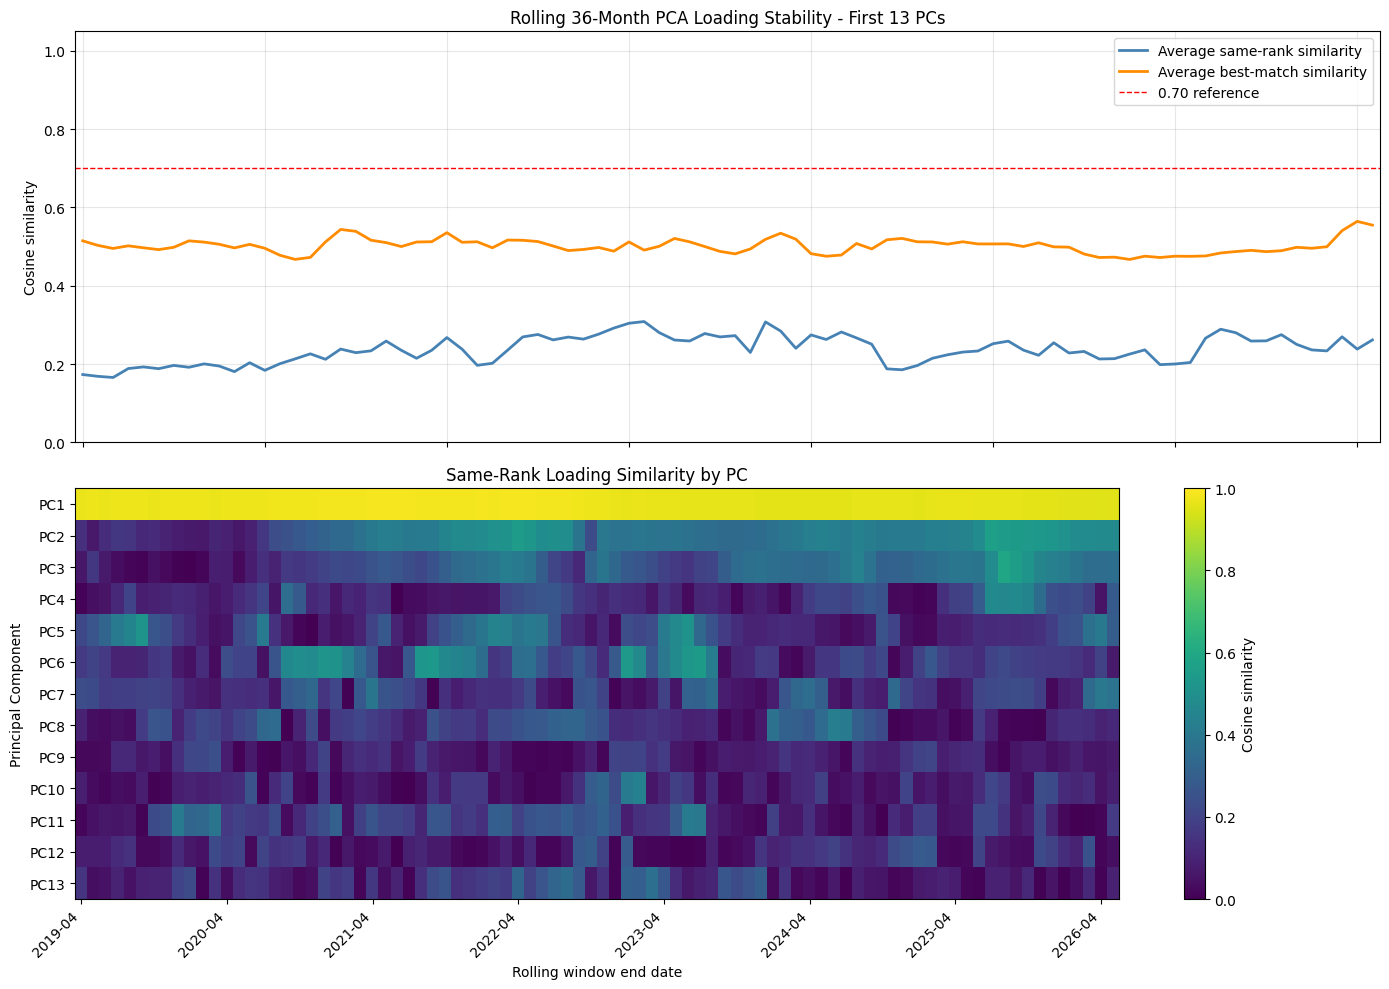

In [11]:
# Visualize rolling loading stability
# Use integer window positions for both panels so the shared x-axis lines up with imshow.
x_pos = np.arange(len(same_rank_stability.index))
xticks = np.arange(0, len(same_rank_stability.index), 12)
xtick_labels = [same_rank_stability.index[i].strftime("%Y-%m") for i in xticks]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(x_pos, same_rank_stability.mean(axis=1).to_numpy(),
             color="steelblue", linewidth=2, label="Average same-rank similarity")
axes[0].plot(x_pos, best_match_stability.mean(axis=1).to_numpy(),
             color="darkorange", linewidth=2, label="Average best-match similarity")
axes[0].axhline(0.7, color="red", linestyle="--", linewidth=1, label="0.70 reference")
axes[0].set_title("Rolling 36-Month PCA Loading Stability - First 13 PCs")
axes[0].set_ylabel("Cosine similarity")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(
    same_rank_stability.T,
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
axes[1].set_yticks(range(N_ROLLING_PCS))
axes[1].set_yticklabels(score_cols)
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(xtick_labels, rotation=45, ha="right")
axes[1].set_title("Same-Rank Loading Similarity by PC")
axes[1].set_xlabel("Rolling window end date")
axes[1].set_ylabel("Principal Component")
plt.colorbar(im, ax=axes[1], label="Cosine similarity")

plt.tight_layout()
plt.show()
